<a href="https://colab.research.google.com/github/radhasundar/datamining/blob/main/exercise10a_kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Excercise 10a- K-Means -Clustering**

import the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler



create the dataset

In [ ]:
data= {
    'Age':[18,20,21,23,30,32,35,37,45,48,50,52],
    'Income':[18000,22000,25000,28000,45000,48000,52000,55000,75000,82000,88000,95000]
}


In [ ]:
#convert data into dataframe
df=pd.DataFrame(data)
df


,Age,Income
0,18,18000
1,20,22000
2,21,25000
3,23,28000
4,30,45000
5,32,48000
6,35,52000
7,37,55000
8,45,75000
9,48,82000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     12 non-null     int64
 1   Income  12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes


In [ ]:
df.shape

(12, 2)

check for null values

In [ ]:
df.isnull().any()

,0
Age,False
Income,False


In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df[['Age','Income']])

In [ ]:
# print standardized values
print("\n standardized data: ")
print(X_scaled)


 standardized data: 
[[-1.37820373 -1.34567249]
 [-1.20857866 -1.19077494]
 [-1.12376612 -1.07460177]
 [-0.95414105 -0.95842861]
 [-0.36045328 -0.30011401]
 [-0.19082821 -0.18394084]
 [ 0.0636094  -0.02904329]
 [ 0.23323448  0.08712987]
 [ 0.91173478  0.86161764]
 [ 1.16617239  1.13268836]
 [ 1.33579746  1.36503469]
 [ 1.50542254  1.6361054 ]]


In [ ]:
# Create K-Means model
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)

In [ ]:
#perform clustering
df['Cluster']=kmeans.fit_predict(X_scaled)


In [ ]:
#display clustered data
print("\n clustered data:")
print(df)


 clustered data:
    Age  Income  Cluster
0    18   18000        2
1    20   22000        2
2    21   25000        2
3    23   28000        2
4    30   45000        0
5    32   48000        0
6    35   52000        0
7    37   55000        0
8    45   75000        1
9    48   82000        1
10   50   88000        1
11   52   95000        1


In [ ]:
# display clustered centroids
print("\n cluster centroid: ")
print(kmeans.cluster_centers_)


 cluster centroid: 
[[-0.0636094  -0.10649207]
 [ 1.22978179  1.24886152]
 [-1.16617239 -1.14236945]]


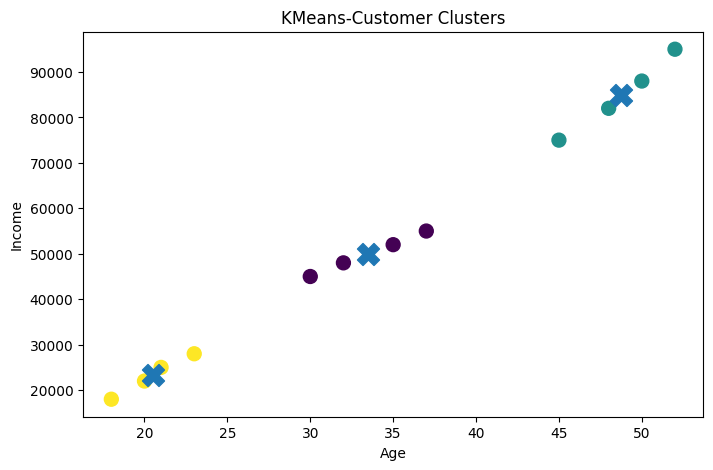

In [ ]:
#plot the clusters
plt.figure(figsize=(8,5))
plt.scatter(
    df['Age'],
    df['Income'],
    c=df['Cluster'],
   s=100
)

#plot cluster centroids
centroids=scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
      s=250,
    marker='X'
)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("KMeans-Customer Clusters")
plt.show()

Evaluate the cluster using Silhoutte score

In [ ]:
score=silhouette_score(X_scaled,df['Cluster'])

In [ ]:
print('Silhouette Score:', score)

Silhouette Score: 0.7327207057602462


Interpreting the Overall Score (Average) 0.71 - 1.0: A strong and clear cluster structure has been found. 0.51-0.70: A reasonable or decent cluster structure is present. 0.26- 0.50: The cluster structure is weak and may be artificial. Below 0.25: There is no substantial or meaningful cluster structure